In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.metrics import pairwise_distances
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

from sklearn.decomposition import PCA
from sklearn import metrics

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
text_data_path = "./text/amazon_alexa.tsv"
text_data = pd.read_csv(text_data_path, delimiter='\t')['verified_reviews']
text_data.head(10)

0                                        Love my Echo!
1                                            Loved it!
2    Sometimes while playing a game, you can answer...
3    I have had a lot of fun with this thing. My 4 ...
4                                                Music
5    I received the echo as a gift. I needed anothe...
6    Without having a cellphone, I cannot use many ...
7    I think this is the 5th one I've purchased. I'...
8                                          looks great
9    Love it! I’ve listened to songs I haven’t hear...
Name: verified_reviews, dtype: object

In [ ]:
data = pd.read_csv(text_data_path, delimiter='\t')
y_true = data['rating']
print(y_true)

0       5
1       5
2       4
3       5
4       5
       ..
3145    5
3146    5
3147    5
3148    5
3149    4
Name: rating, Length: 3150, dtype: int64


In [ ]:
documents = []

stemmer = WordNetLemmatizer()

for sentence in text_data:
    # Remove all the special characters
    document = re.sub(r'\W', ' ', str(sentence))
    
    # remove all single characters
    document = re.sub(r'\s+[a-zA-Z]\s+', ' ', document)
    
    # Remove single characters from the start
    document = re.sub(r'\^[a-zA-Z]\s+', ' ', document) 
    
    # Substituting multiple spaces with single space
    document = re.sub(r'\s+', ' ', document, flags=re.I)
    
    # Removing prefixed 'b'
    document = re.sub(r'^b\s+', '', document)
    
    # Converting to Lowercase
    document = document.lower()
    
    # Lemmatization
    document = document.split()

    document = [stemmer.lemmatize(word) for word in document]
    document = ' '.join(document)
    
    documents.append(document)

In [ ]:
vectorizer = CountVectorizer(max_features=20, stop_words=stopwords.words('english'))
text_data_transformed = vectorizer.fit_transform(documents).toarray()

text_data_transformed = TfidfTransformer().fit_transform(text_data_transformed).toarray()

text_data_transformed = pd.DataFrame(text_data_transformed)

print('data shape: ', text_data_transformed.shape)

text_data_transformed = text_data_transformed.sort_values(by=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

data shape:  (3150, 20)


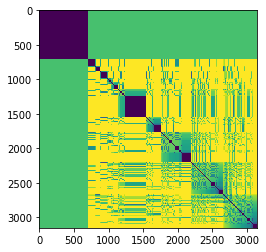

In [ ]:
p = pairwise_distances(text_data_transformed, metric='euclidean')
plt.imshow(p, interpolation='nearest')

In [ ]:
vectorizer.get_feature_names_out()

array(['alexa', 'device', 'dot', 'easy', 'echo', 'get', 'good', 'great',
       'like', 'love', 'music', 'one', 'product', 'set', 'sound',
       'speaker', 'thing', 'use', 'wa', 'work'], dtype=object)

## Testando Algoritmos de Clustering

In [ ]:
n_clusters = 5

kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(text_data_transformed)
agglomerative = AgglomerativeClustering(n_clusters).fit(text_data_transformed)

P = pairwise_distances(text_data_transformed)
spectral = SpectralClustering(
    n_clusters=n_clusters, 
    affinity='precomputed_nearest_neighbors', 
    n_neighbors=5, random_state=0
    ).fit(P)

y_kmeans = kmeans.labels_
y_agglomerative = agglomerative.labels_
y_spectral = spectral.labels_

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_spectral_embedding.py:261: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  "Graph is not fully connected, spectral embedding may not work as expected."


## Avaliação dos Clusters

In [ ]:
sil_kmeans = metrics.silhouette_score(text_data_transformed, y_kmeans, metric='euclidean')
sil_agglomerative = metrics.silhouette_score(text_data_transformed, y_agglomerative, metric='euclidean')
sil_spectral = metrics.silhouette_score(text_data_transformed, y_spectral, metric='euclidean')

print('Silhueta kmeans', sil_kmeans)
print('Silhueta agglomerative', sil_agglomerative)
print('Silhueta spectral', sil_spectral)

print('\n')

nmi_kmeans = metrics.normalized_mutual_info_score(y_true, y_kmeans)
nmi_agglomerative = metrics.normalized_mutual_info_score(y_true, y_agglomerative)
nmi_spectral = metrics.normalized_mutual_info_score(y_true, y_spectral)

print('NMI Kmeans: ', nmi_kmeans)
print('NMI Aglomerativo: ', nmi_agglomerative)
print('NMI Spectral: ', nmi_spectral)

Silhueta kmeans 0.18597754734276256
Silhueta agglomerative 0.15077120639426914
Silhueta spectral -0.06783232658725927


NMI Kmeans:  0.005217161277678838
NMI Aglomerativo:  0.0056895335002524975
NMI Spectral:  0.0032030109668223774


## Visualização dos Clusters

(3150, 2)


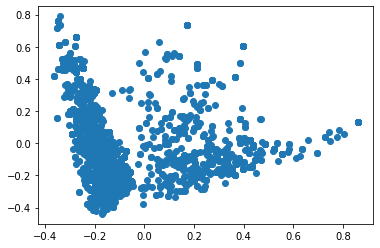

In [ ]:
X = PCA(n_components=2).fit_transform(text_data_transformed)
print(X.shape)
plt.scatter(X[:, 0], X[:, 1])